# **Практическая работа №9. Работа с векторными данными в GeoPandas**

In [1]:
%%capture
%pip install geopandas leafmap mapclassify # Устанавливаем библиотеку GeoPandas и необходимые зависимости

## **Задание №1. Операции с массивами NumPy и геопространственными координатами**


1. Создайте двумерный массив NumPy, содержащий широту и долготу следующих городов: Токио (35.6895, 139.6917), Нью-Йорк (40.7128, -74.0060), Лондон (51.5074, -0.1278) и Париж (48.8566, 2.3522).


In [ ]:
import numpy as np

coords_deg = np.array([
    [35.6895, 139.6917],
    [40.7128, -74.0060],
    [51.5074, -0.1278],
    [48.8566, 2.3522],
])
coords_deg

2. Преобразуйте значения широты и долготы из градусов в радианы с помощью функции np.radians().


In [ ]:
coords_rad = np.radians(coords_deg)
coords_rad



3. Рассчитайте поэлементную разницу между координатами Токио и других городов в радианах.

In [ ]:
diff_tokyo = coords_rad - coords_rad[0]
diff_tokyo

## **Задание 2. Операции с DataFrame Pandas и геопространственными данными**


1. Загрузите набор данных о городах мира по следующему URL с помощью Pandas: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv


In [2]:
import pandas as pd

url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
df = pd.read_csv(url)
df

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.58330,32.53330,75000
1,2,Fort Portal,UGA,0.67100,30.27500,42670
2,3,Potenza,ITA,40.64200,15.79900,69060
3,4,Campobasso,ITA,41.56300,14.65600,50762
4,5,Aosta,ITA,45.73700,7.31500,34062
...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000
1247,1248,Singapore,SGP,1.29303,103.85582,5183700


2. Отобразите первые 5 строк и проверьте наличие отсутствующих значений.


In [3]:
df.head(), df.isna().sum()

(   id         name country  latitude  longitude  population
 0   1        Bombo     UGA    0.5833    32.5333       75000
 1   2  Fort Portal     UGA    0.6710    30.2750       42670
 2   3      Potenza     ITA   40.6420    15.7990       69060
 3   4   Campobasso     ITA   41.5630    14.6560       50762
 4   5        Aosta     ITA   45.7370     7.3150       34062,
 id            0
 name          0
 country       0
 latitude      0
 longitude     0
 population    0
 dtype: int64)

3. Отфильтруйте набор данных, чтобы включить только города с населением более 1 миллиона человек.


In [4]:
pop_col = next(c for c in ["population", "pop", "POP", "Population"] if c in df.columns)
df_1m = df[df[pop_col] > 1_000_000].copy()
df_1m

,id,name,country,latitude,longitude,population
97,98,Turin,ITA,45.07039,7.66996,1652000
103,104,Lille,FRA,50.64997,3.08001,1044000
123,124,San Bernardino,USA,34.12038,-117.30003,1745000
124,125,Bridgeport,USA,41.17998,-73.19996,1018000
126,127,Manchester,GBR,53.50042,-2.24799,2230000
...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000
1247,1248,Singapore,SGP,1.29303,103.85582,5183700


4. Сгруппируйте города по странам и рассчитайте общую численность населения для каждой страны.


In [5]:
country_col = next(c for c in ["country", "Country", "COUNTRY"] if c in df_1m.columns)
pop_by_country = df_1m.groupby(country_col, as_index=False)[pop_col].sum().sort_values(pop_col, ascending=False)
pop_by_country.head(10)

,country,population
18,CHN,203615000
102,USA,134565743
46,IND,134458000
14,BRA,71900406
53,JPN,61636000
64,MEX,33318000
82,RUS,25533000
72,PAK,24504000
45,IDN,20886000
69,NGA,20462000




5. Отсортируйте города по населению в порядке убывания и отобразите первые 10 городов.

In [6]:
df_1m.sort_values(pop_col, ascending=False).head(10)

,id,name,country,latitude,longitude,population
1239,1240,Tokyo,JPN,35.68502,139.75141,35676000
1224,1225,New York,USA,40.74998,-73.98002,19040000
1230,1231,Mexico City,MEX,19.44244,-99.13099,19028000
1240,1241,Mumbai,IND,19.01699,72.85699,18978000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1148,1149,Delhi,IND,28.66999,77.23000,15926000
1238,1239,Shanghai,CHN,31.21645,121.43650,14987000
1243,1244,Kolkata,IND,22.49497,88.32468,14787000
1175,1176,Dhaka,BGD,23.72306,90.40858,12797394
1217,1218,Buenos Aires,ARG,-34.60250,-58.39753,12795000


## **Задание №3. Создание и обработка GeoDataFrames с помощью GeoPandas**


1. Загрузите набор данных о зданиях Нью-Йорка из файла GeoJSON с помощью GeoPandas: https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson

In [3]:
import geopandas as gpd

url = "https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson"
gdf = gpd.read_file(url)
gdf

,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
0,2,15.05,23.30,19.18,6365.72,36,New York,"POLYGON ((-74.00129 40.71992, -74.00061 40.719..."
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."
...,...,...,...,...,...,...,...,...
1201,9764,26.54,22.30,24.42,696.24,36,New York,"POLYGON ((-73.97463 40.72411, -73.97467 40.724..."
1202,9765,10.44,16.53,13.48,2859.96,36,New York,"POLYGON ((-73.98495 40.71911, -73.98436 40.718..."
1203,9766,10.44,13.87,12.16,2859.96,36,New York,"POLYGON ((-73.98495 40.71911, -73.98436 40.718..."
1204,9774,13.76,NaN,13.76,1612.84,36,New York,"POLYGON ((-73.99154 40.71045, -73.99173 40.710..."


2. Создайте график контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


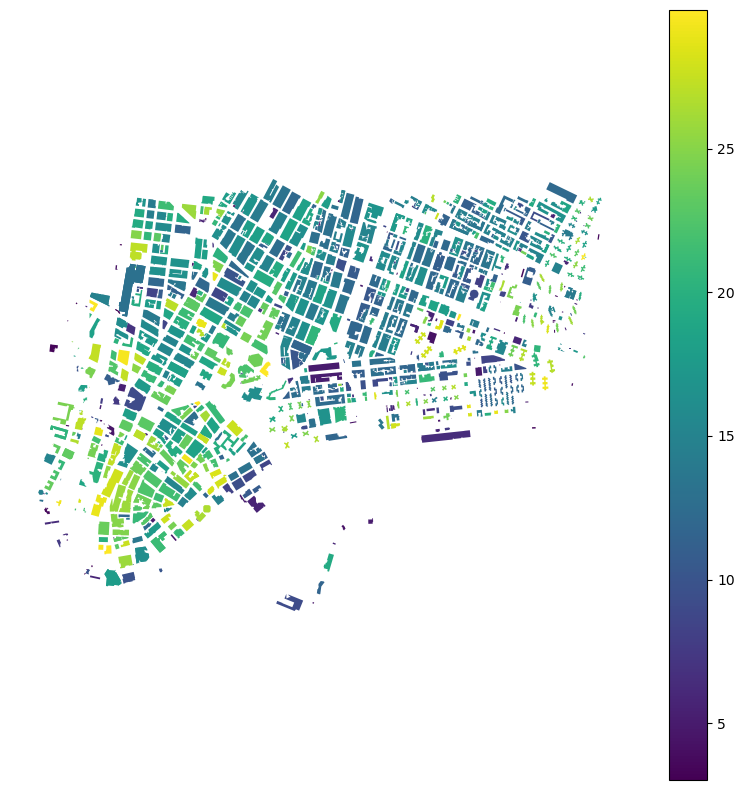

In [4]:
import matplotlib.pyplot as plt

gdf.plot(column="height_MS", legend=True, linewidth=0, figsize=(10, 10))
plt.axis("off")
plt.show()

3. Создайте интерактивную карту контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


In [1]:
import leafmap.leafmap as leafmap

In [5]:
m = leafmap.Map()
m.add_gdf(gdf, layer_name="NYC buildings", column="height_MS")
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

4. Рассчитайте среднюю высоту зданий (используйте столбец `height_MS`).


In [18]:
mean_h = gdf["height_MS"].mean()
mean_h

np.float64(15.454691136974038)

5. Выберите здания с высотой, превышающей среднюю высоту.


In [19]:
gdf_tall = gdf[gdf["height_MS"] > mean_h].copy()
gdf_tall

,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."
5,38,18.84,NaN,18.84,1151.88,36,New York,"POLYGON ((-74.01574 40.70672, -74.01537 40.706..."
...,...,...,...,...,...,...,...,...
1196,9714,19.90,19.15,19.52,1230.57,36,New York,"POLYGON ((-73.98328 40.71861, -73.9826 40.7184..."
1198,9752,19.35,NaN,19.35,4080.25,36,New York,"POLYGON ((-73.99528 40.70245, -73.99568 40.702..."
1199,9754,24.11,47.47,35.79,7137.13,36,New York,"POLYGON ((-74.00084 40.71547, -74.00075 40.715..."
1200,9756,16.20,15.17,15.68,166.41,36,New York,"POLYGON ((-73.99054 40.71271, -73.99045 40.712..."





6. Сохраните GeoDataFrame в новый файл GeoJSON.

In [20]:
gdf_tall.to_file("nyc_buildings_above_mean.geojson", driver="GeoJSON")
"nyc_buildings_above_mean.geojson"

'nyc_buildings_above_mean.geojson'

## **Задание №4. Применение NumPy, Pandas и GeoPandas для обработки и анализа пространственных данных**


1. Используйте Pandas для загрузки набора данных о городах мира по следующему URL: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv


In [23]:
import pandas as pd

url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
df = pd.read_csv(url)
df

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.58330,32.53330,75000
1,2,Fort Portal,UGA,0.67100,30.27500,42670
2,3,Potenza,ITA,40.64200,15.79900,69060
3,4,Campobasso,ITA,41.56300,14.65600,50762
4,5,Aosta,ITA,45.73700,7.31500,34062
...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000
1247,1248,Singapore,SGP,1.29303,103.85582,5183700


2. Отфильтруйте набор данных, чтобы включить только города с широтой между -40 и 60 (т.е. города, расположенные в Северном полушарии или вблизи экватора).


In [24]:
lat_col = next(c for c in ["lat", "latitude", "Lat", "Latitude"] if c in df.columns)
df_f = df[df[lat_col].between(-40, 60)].copy()
df_f

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.58330,32.53330,75000
1,2,Fort Portal,UGA,0.67100,30.27500,42670
2,3,Potenza,ITA,40.64200,15.79900,69060
3,4,Campobasso,ITA,41.56300,14.65600,50762
4,5,Aosta,ITA,45.73700,7.31500,34062
...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000
1247,1248,Singapore,SGP,1.29303,103.85582,5183700


3. Создайте GeoDataFrame из отфильтрованного набора данных, преобразовав широту и долготу в геометрии.


In [ ]:
import geopandas as gpd

lon_col = next(c for c in ["lon", "lng", "longitude", "Long", "Longitude"] if c in df_f.columns)

gdf_c = gpd.GeoDataFrame(
    df_f,
    geometry=gpd.points_from_xy(df_f[lon_col], df_f[lat_col]),
    crs="EPSG:4326"
)
gdf_c

,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.58330,32.53330,75000,POINT (32.5333 0.5833)
1,2,Fort Portal,UGA,0.67100,30.27500,42670,POINT (30.275 0.671)
2,3,Potenza,ITA,40.64200,15.79900,69060,POINT (15.799 40.642)
3,4,Campobasso,ITA,41.56300,14.65600,50762,POINT (14.656 41.563)
4,5,Aosta,ITA,45.73700,7.31500,34062,POINT (7.315 45.737)
...,...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000,POINT (-43.22502 -22.92502)
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000,POINT (-46.62502 -23.55868)
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000,POINT (151.18518 -33.92001)
1247,1248,Singapore,SGP,1.29303,103.85582,5183700,POINT (103.85582 1.29303)


4. Перепроецируйте GeoDataFrame в проекцию Меркатора (EPSG:3857).


In [26]:
gdf_m = gdf_c.to_crs(epsg=3857)
gdf_m

,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.58330,32.53330,75000,POINT (3621590.39 64933.781)
1,2,Fort Portal,UGA,0.67100,30.27500,42670,POINT (3370197.584 74697.086)
2,3,Potenza,ITA,40.64200,15.79900,69060,POINT (1758736.635 4959679.293)
3,4,Campobasso,ITA,41.56300,14.65600,50762,POINT (1631498.457 5095742.084)
4,5,Aosta,ITA,45.73700,7.31500,34062,POINT (814302.075 5738302.989)
...,...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000,POINT (-4811787.216 -2622953.59)
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000,POINT (-5190273.485 -2699722.817)
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000,POINT (16829857.253 -4018066.374)
1247,1248,Singapore,SGP,1.29303,103.85582,5183700,POINT (11561176.998 143951.661)


5. Рассчитайте расстояние (в метрах) между каждым городом и Парижем.


In [28]:
from shapely.geometry import Point

paris = gpd.GeoSeries([Point(2.3522, 48.8566)], crs="EPSG:4326").to_crs(epsg=3857).iloc[0]
gdf_m["dist_to_paris_m"] = gdf_m.geometry.distance(paris)
gdf_m[["dist_to_paris_m"]].head()

,dist_to_paris_m
0,7.039170e+06
1,6.913985e+06
2,1.976630e+06
3,1.791525e+06
4,7.534054e+05




6. Отобразите города на карте мира, раскрасив точки в зависимости от их расстояния до Парижа.

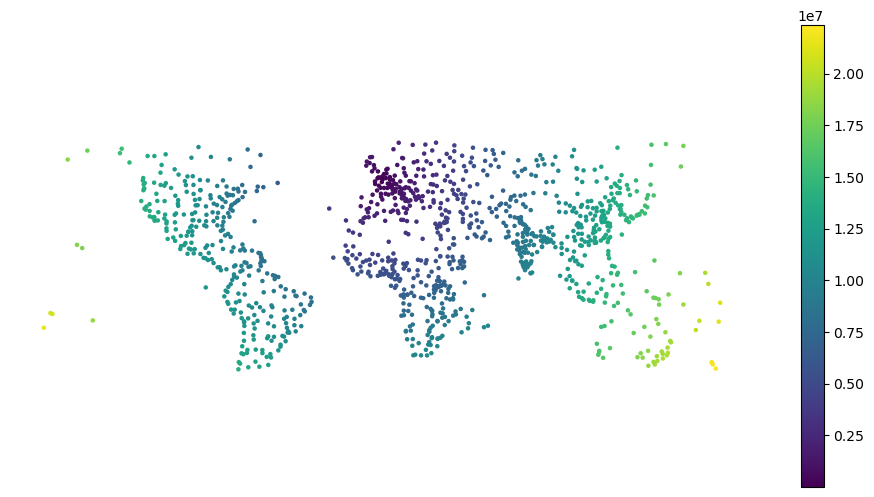

In [29]:
import matplotlib.pyplot as plt

gdf_m.plot(column="dist_to_paris_m", legend=True, markersize=5, figsize=(12, 6))
plt.axis("off")
plt.show()